<a href="https://colab.research.google.com/github/majshal/-dobre-PUM/blob/preprocessing/PUM_2_1103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pobierz dane dotyczące scoringu kredytowego

*Pracujesz jako analityk danych w globalnej firmie finansowej. Przez lata firma gromadziła podstawowe dane bankowe i wiele informacji związanych z kredytami. Kierownictwo chce zbudować inteligentny system do segregowania ludzi w przedziałach oceny kredytowej, aby zmniejszyć wysiłek ręczny.*

**Zadanie na dziś: przygotować dane do modelu**

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer

import danych

In [ ]:
  # pip install kagglehub[pandas-datasets]
  import kagglehub
  from kagglehub import KaggleDatasetAdapter

  # Set the path to the file you'd like to load
  file_path = "train.csv"

  # Load the latest version
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path,
  )

  print("First 5 records:", df.head())

<ipython-input-53-db52f5663265>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path,


First 5 records:        ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utiliz

/usr/local/lib/python3.11/dist-packages/kagglehub/pandas_datasets.py:91: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


**Poznaj dane:**

1.   sprawdź wymiary i typy kolumn
2.   usuń duplikaty
3.   usuń zdbędne kolumny
4.   sprawdz liczbę braków danych w poszczególnych kolumnach






In [ ]:
#1
df.info()
#2
df = df.drop_duplicates()
#3
df.drop(columns={'ID', 'Customer_ID', 'SSN', 'Name'}, inplace=True)
#4
missing_data = df.isnull().sum()
print(missing_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Usuń kolumny, które nie będą wykorzystywane w analizie ['ID','Customer_ID','SSN','Name']

usuń niektore z zbędnych znakow ('_','-'), zmień puste komorki na nan

In [ ]:
df.columns = df.columns.str.replace('_', ' ')
df.columns = df.columns.str.replace('-', ' ')
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)


Zmień nazwy miesiecy na zmienne liczbowe zgodnie z kolejnością miesięcy

In [ ]:
month_mapping = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

if 'Month' in df.columns:
  df['Month'] = df['Month'].map(month_mapping)

df['Type of Loan']
df['Type of Loan'] = df['Type of Loan'].fillna('')
df['Type of Loan'] = df['Type of Loan'].str.replace(r'\band\b', '', regex=True).str.strip() #removes "and"

# Split and clean the values
df_type_of_loan = df['Type of Loan'].str.split(r',\s*')  # Handles different spacing

# Use MultiLabelBinarizer
mlb = MultiLabelBinarizer()
dt = mlb.fit_transform(df_type_of_loan.to_list())  # Ensure correct format

# Convert to DataFrame
encoded_df = pd.DataFrame(data=dt, columns=mlb.classes_)

# Merge with original DataFrame and drop old column
df = df.join(encoded_df).drop(columns=['Type of Loan'])

print(df.head())

   Month   Age Occupation Annual Income  Monthly Inhand Salary  \
0    NaN    23  Scientist      19114.12            1824.843333   
1    NaN    23  Scientist      19114.12                    NaN   
2    NaN  -500  Scientist      19114.12                    NaN   
3    NaN    23  Scientist      19114.12                    NaN   
4    NaN    23  Scientist      19114.12            1824.843333   

   Num Bank Accounts  Num Credit Card  Interest Rate Num of Loan  \
0                  3                4              3           4   
1                  3                4              3           4   
2                  3                4              3           4   
3                  3                4              3           4   
4                  3                4              3           4   

   Delay from due date  ...    Auto Loan  Credit-Builder Loan  \
0                    3  ...  0         1                    1   
1                   -1  ...  0         1                    1   

Zakoduj zmienne tekstowe: 'Occupation', 'Type_of_Loan', 'Payment_Behaviour', 'Credit_Mix', użyj LabelEncodera

In [ ]:
label_encoder = LabelEncoder()

for column in ['Occupation', 'Payment Behaviour', 'Credit Mix']:
    if column in df.columns:
        df[column] = label_encoder.fit_transform(df[column].astype(str))


Przelicz kolumne Credit_History_Age na liczbę mięsiecy


In [ ]:
def convert_credit_history_age(age_str):
    if pd.isna(age_str):
        return np.nan
    else:
        try:
            years, months = map(int, age_str.split(' ')[0].split('Y'))
            return years * 12 + months
        except (ValueError, AttributeError):
            return np.nan

if 'Credit History Age' in df.columns:
    df['Credit History Age in Months'] = df['Credit History Age'].apply(convert_credit_history_age)



Zmien inne zmienne na numeryczne

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass


Uzupełnij braki w kolumnie Monthly_Inhand_Salary,  Annual_Income, .. średnią

In [ ]:
for col in ['Monthly Inhand Salary', 'Annual Income', 'Num of Bank Accounts', 'Num of Credit Card', 'Interest Rate', 'Num of Loan', 'Delay from due date', 'Outstanding Debt', 'Credit History Age in Months', 'Total EMI per month']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())


Narysuj rozkłady zmiennych 'Annual_Income', 'Monthly_Balance'

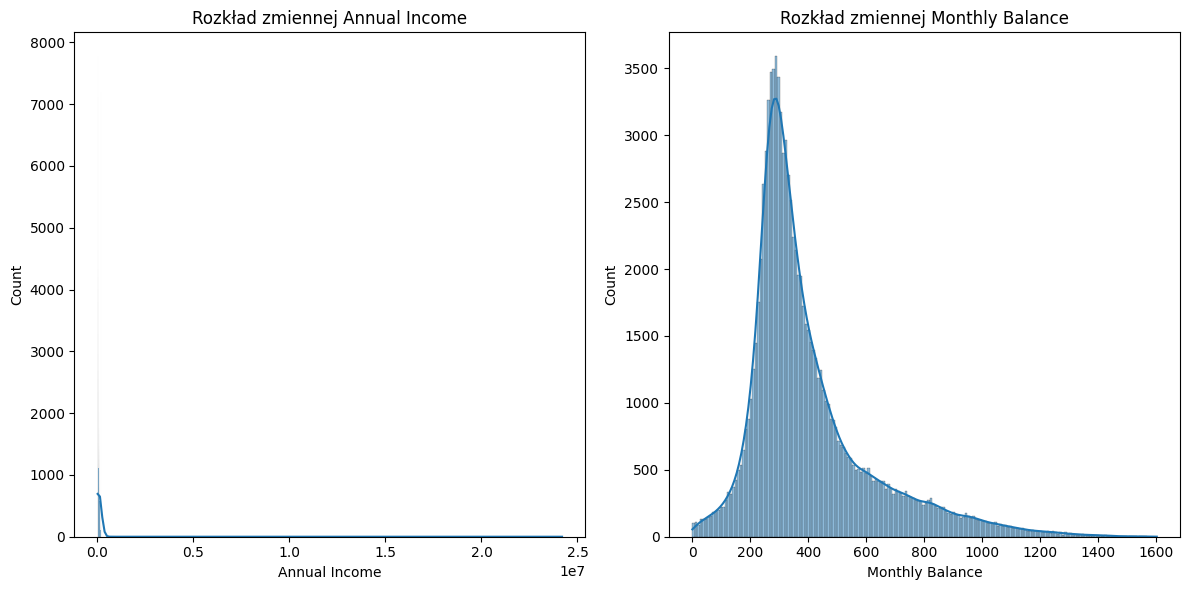

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income'], kde=True)
plt.title('Rozkład zmiennej Annual Income')

plt.subplot(1, 2, 2)
sns.histplot(df['Monthly Balance'], kde=True)
plt.title('Rozkład zmiennej Monthly Balance')

plt.tight_layout()
plt.show()


usuń wartości odstające (w przypadku wieku wszystkie ujemne i te powyzej 100 lat)

In [ ]:
if 'Age' in df.columns:
    df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]


Uzupełnij braki w kolumnie Monthly_Inhand_Salary, Annual_Income średnią

In [ ]:
for col in ['Monthly Inhand Salary', 'Annual Income', 'Num of Bank Accounts', 'Num of Credit Card', 'Interest Rate', 'Num of Loan', 'Delay from due date', 'Outstanding Debt', 'Credit History Age in Months', 'Total EMI per month']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())


Zastąp outliery (wartości poniżej 0 i powyżej 100) w kolumnie 'Age' średnią

In [ ]:
if 'Age' in df.columns:
    mean_age = df['Age'].mean()
    df.loc[df['Age'] < 0, 'Age'] = mean_age
    df.loc[df['Age'] > 100, 'Age'] = mean_age


użyj IQR, aby wyznaczyć wartości odstające w kolumnie Annual_Income oraz Monthly_Inhand_Salary, następnie zastąp te wartości wartości medianą

In [ ]:
Q1_salary = df['Monthly Inhand Salary'].quantile(0.25)
Q3_salary = df['Monthly Inhand Salary'].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary

lower_bound_salary = Q1_salary - 1.5 * IQR_salary
upper_bound_salary = Q3_salary + 1.5 * IQR_salary

df['Monthly Inhad Salary'] = np.where((df['Monthly Inhand Salary'] < lower_bound_salary) | (df['Monthly Inhand Salary'] > upper_bound_salary), df['Monthly Inhand Salary'].median(), df['Monthly Inhand Salary'])

Q1_income = df['Annual Income'].quantile(0.25)
Q3_income = df['Annual Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

df['Annual Income'] = np.where((df['Annual Income'] < lower_bound_income) | (df['Annual Income'] > upper_bound_income), df['Annual Income'].median(), df['Annual Income'])

zbadaj korelacje między zmiennymi, wyznacz heatmapę, wyznacz które kolumny mają korelacje wyższa niż 0.3

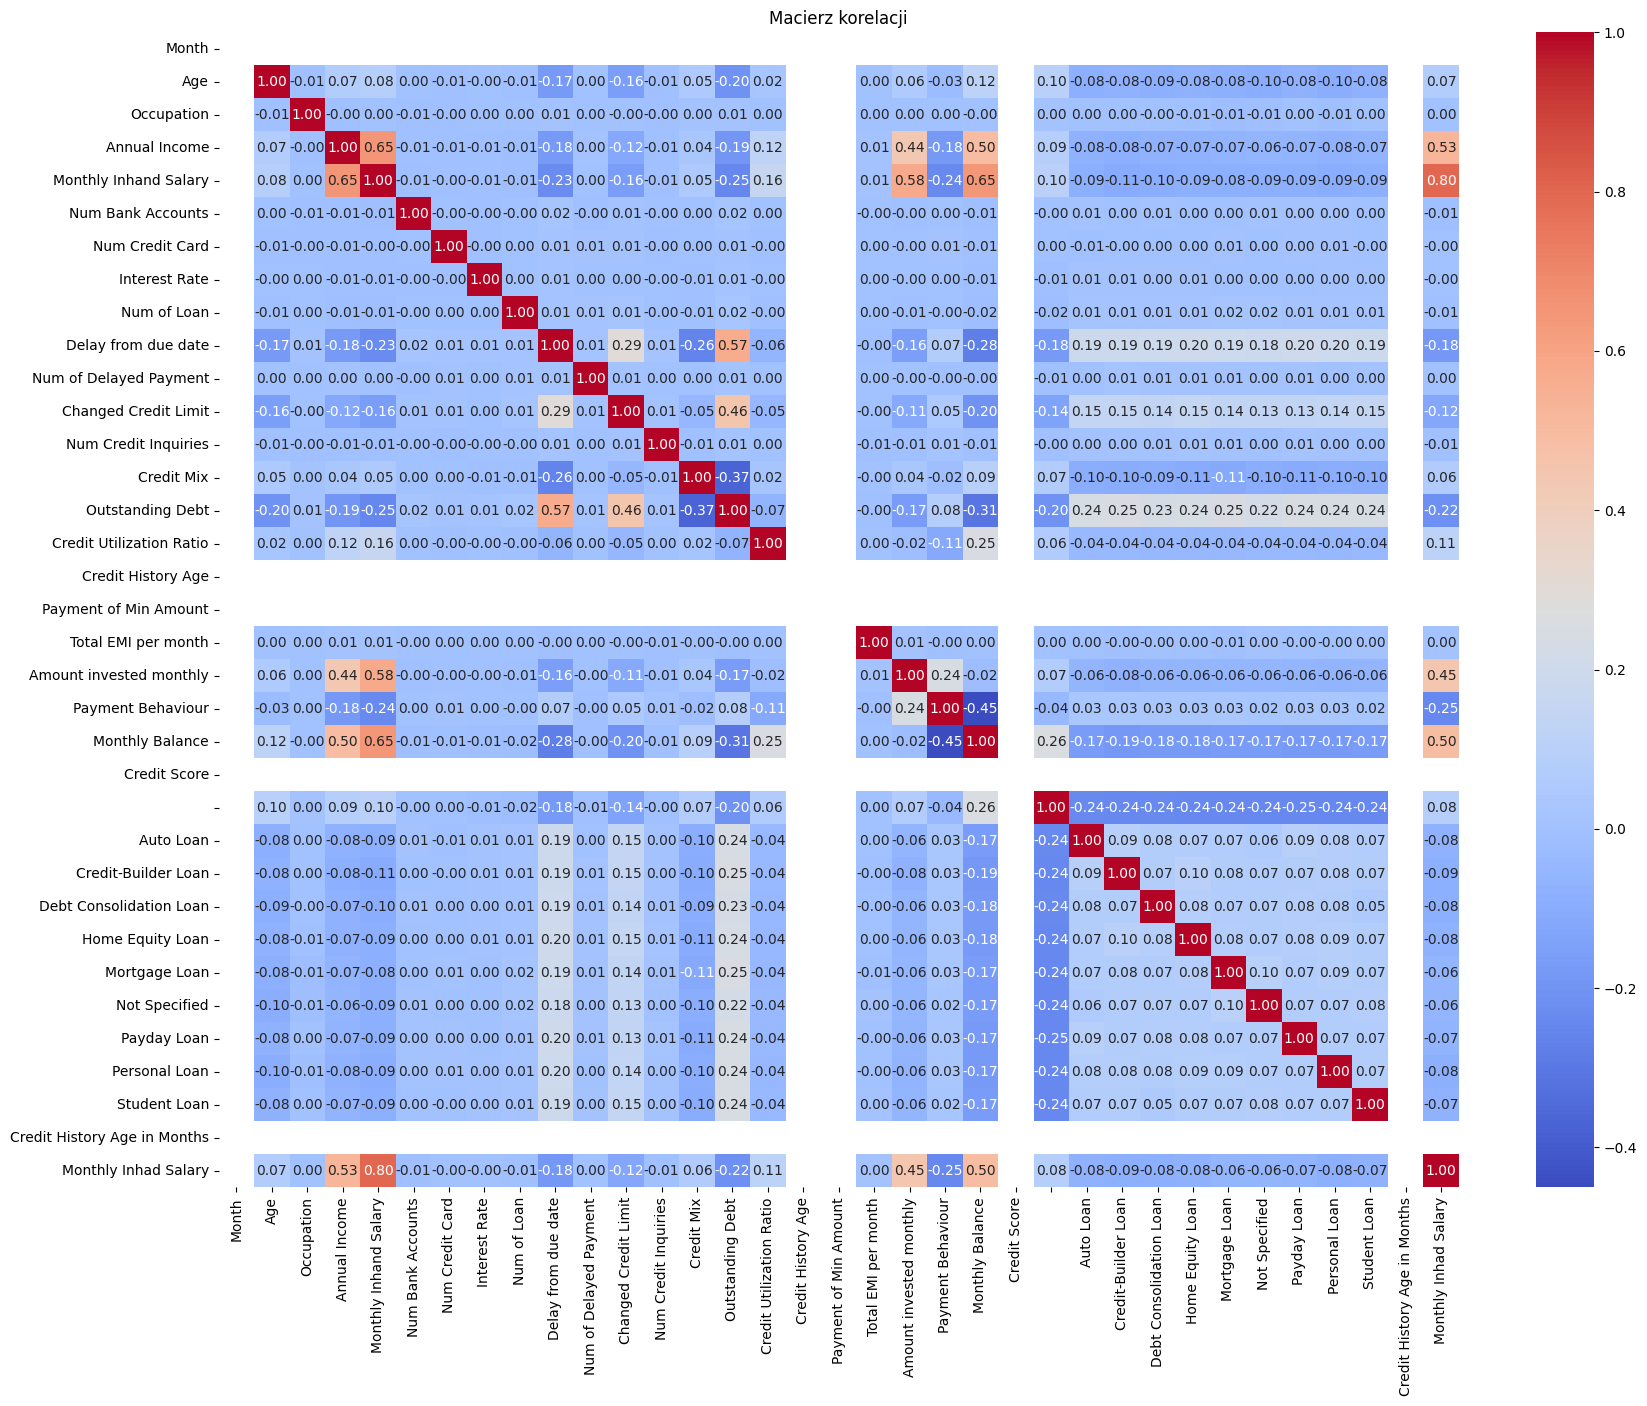

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji')
plt.show()


użyj MinMaxScaler’a do transformacji kolumn: ['Age', 'Annual_Income','Monthly_Inhand_Salary', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Age', 'Annual Income', 'Monthly Inhand Salary', 'Delay from due date', 'Num of Delayed Payment', 'Outstanding Debt', 'Credit History Age in Months', 'Total EMI per month', 'Monthly Balance']

scaler = MinMaxScaler()

for col in columns_to_scale:
  if col in df.columns:
    df[col] = scaler.fit_transform(df[[col]])


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Wykorzystując dokumentację sklearn.decomposition, wykonaj na danych PCA, zachowując 90% wariancji

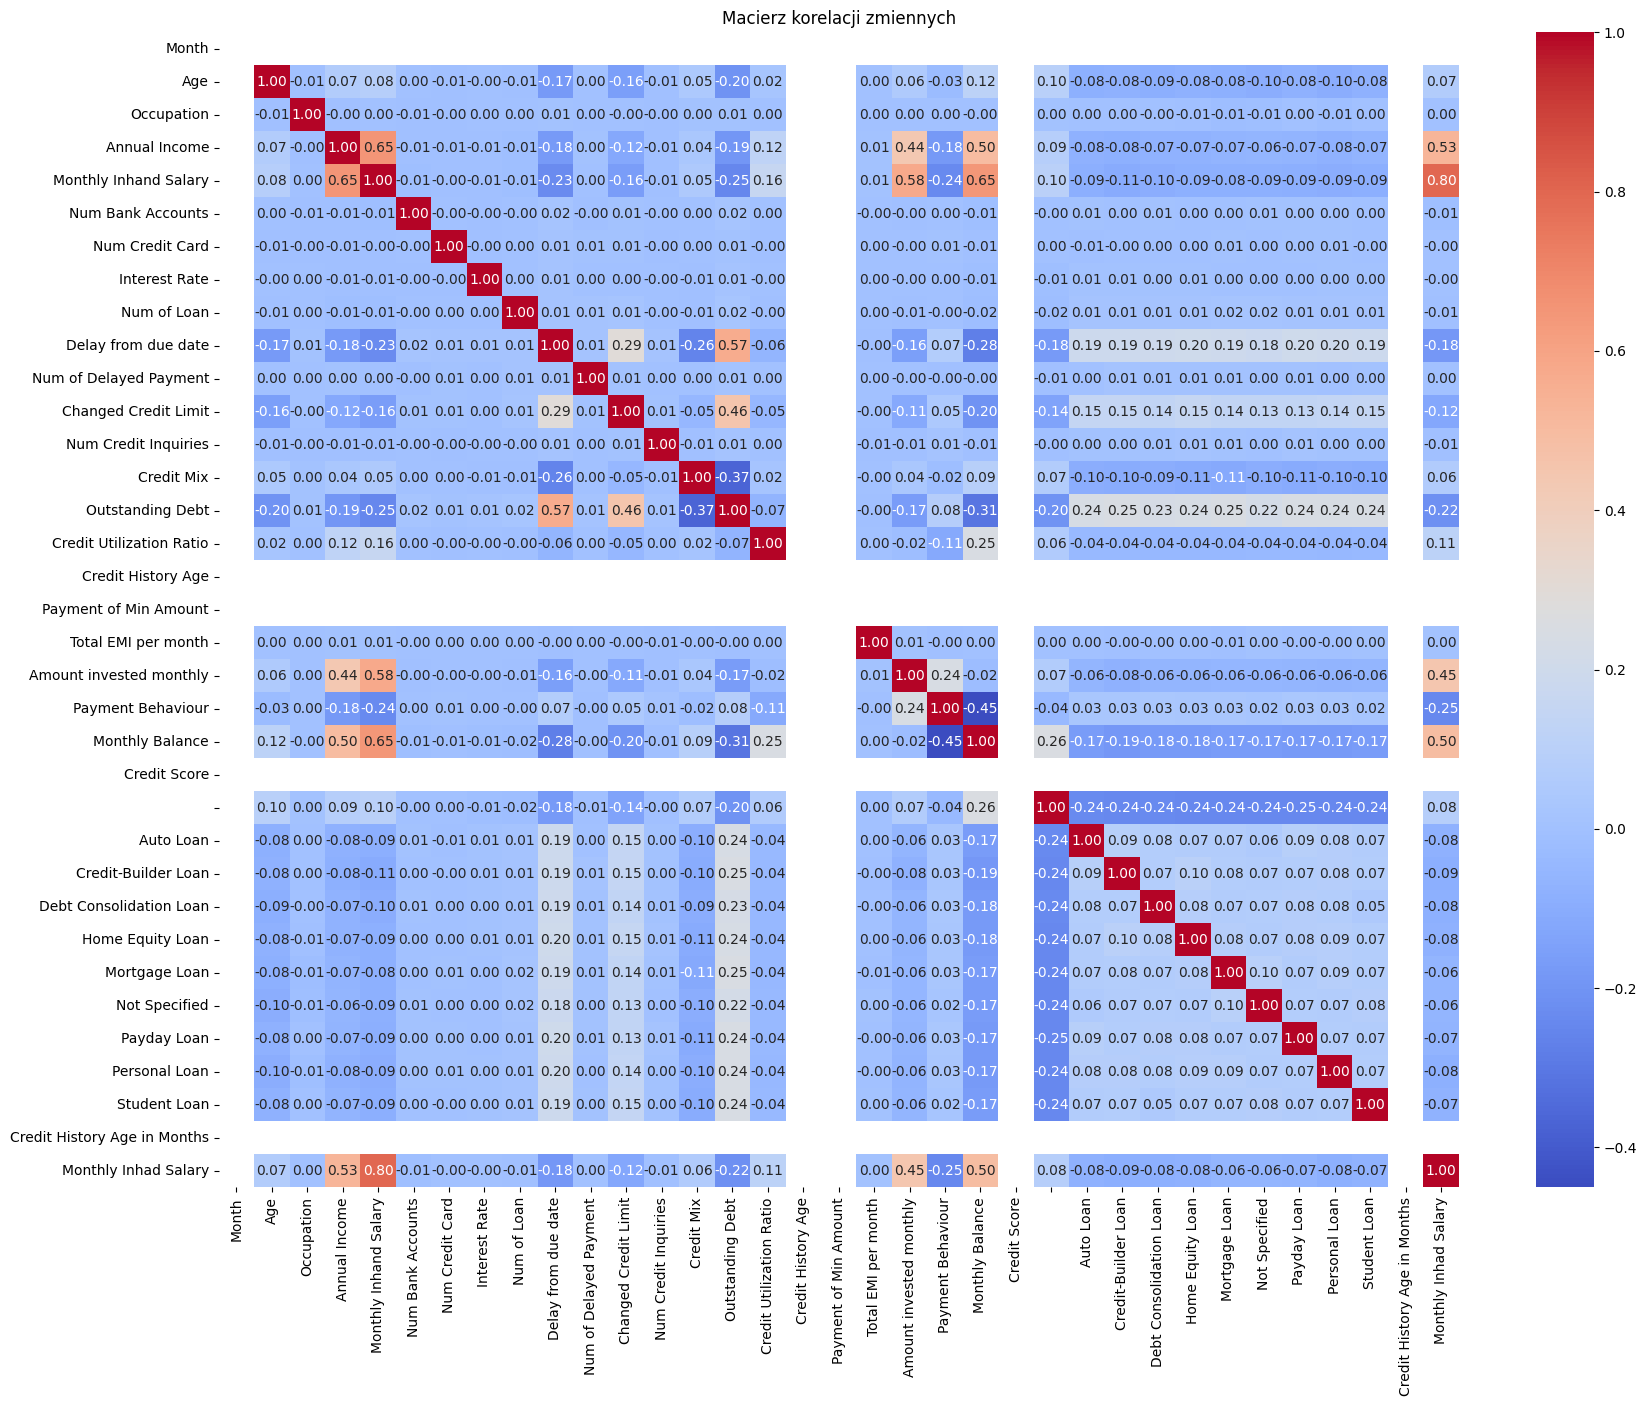

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji zmiennych')
plt.show()
